In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp

## Задача 1

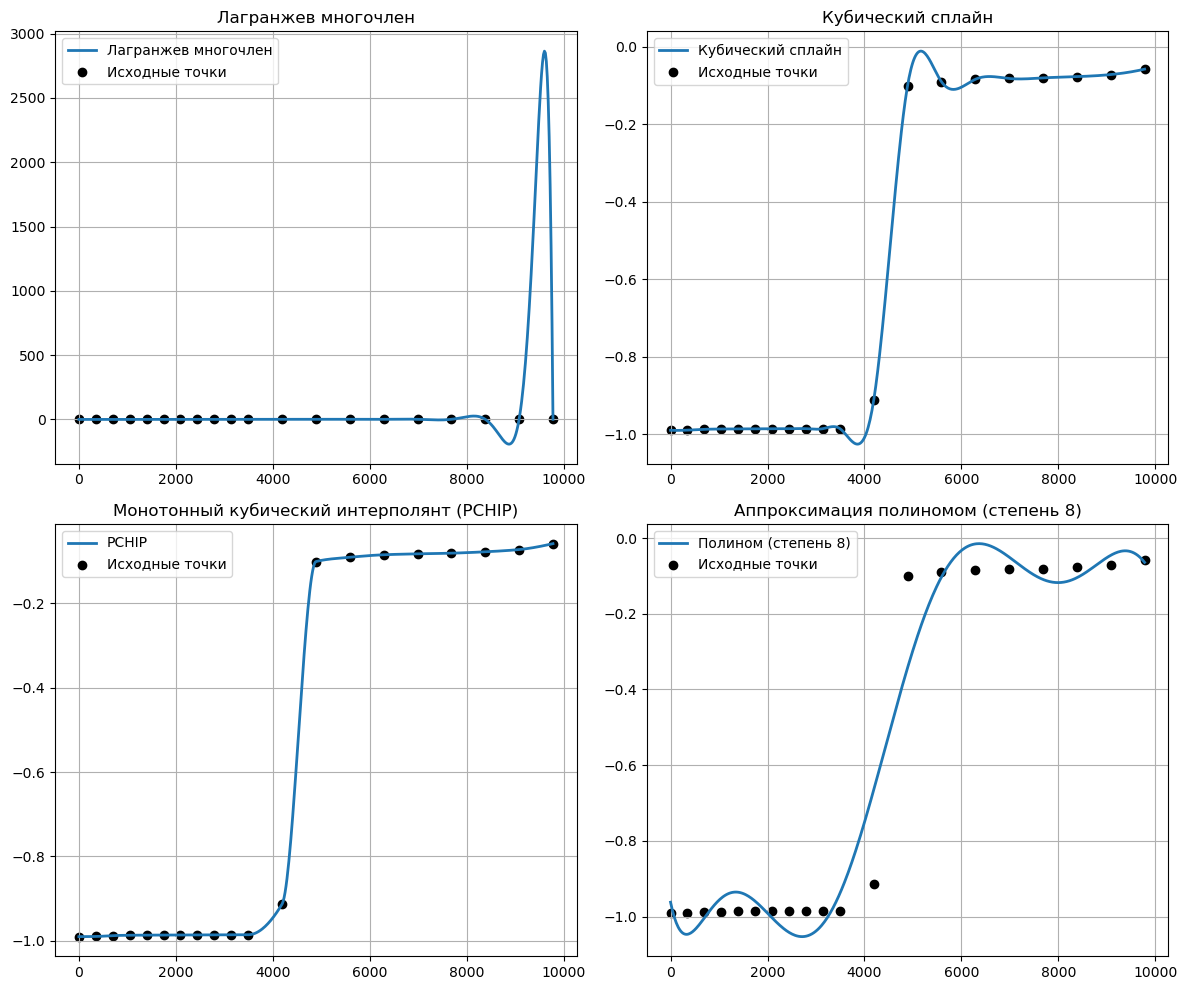

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline, PchipInterpolator


with np.load('data_interp.npz') as data:
    x1, y1 = data['x1'], data['y1']


x_dense = np.linspace(np.min(x1), np.max(x1), 500)

# (a) Лагранжев многочлен
lagrange_poly = lagrange(x1, y1)
y_lagrange = lagrange_poly(x_dense)

# (b) Кубический сплайн
cs = CubicSpline(x1, y1)
y_cs = cs(x_dense)

# (c) Монотонный кубический интерполянт (PCHIP)
pchip = PchipInterpolator(x1, y1)
y_pchip = pchip(x_dense)

# (d) Аппроксимация полиномом с использованием np.polyfit и np.polyval
degree = 8
coeffs = np.polyfit(x1, y1, degree)
y_polyfit = np.polyval(coeffs, x_dense)

# Создаём подграфики 2x2 для каждого метода
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes.flatten()

# Лагранжев многочлен
ax[0].plot(x_dense, y_lagrange, label='Лагранжев многочлен', linewidth=2)
ax[0].scatter(x1, y1, color='black', label='Исходные точки')
ax[0].set_title('Лагранжев многочлен')
ax[0].legend()
ax[0].grid(True)

# Кубический сплайн
ax[1].plot(x_dense, y_cs, label='Кубический сплайн', linewidth=2)
ax[1].scatter(x1, y1, color='black', label='Исходные точки')
ax[1].set_title('Кубический сплайн')
ax[1].legend()
ax[1].grid(True)

# Монотонный кубический интерполянт (PCHIP)
ax[2].plot(x_dense, y_pchip, label='PCHIP', linewidth=2)
ax[2].scatter(x1, y1, color='black', label='Исходные точки')
ax[2].set_title('Монотонный кубический интерполянт (PCHIP)')
ax[2].legend()
ax[2].grid(True)

# Полином
ax[3].plot(x_dense, y_polyfit, label=f'Полином (степень {degree})', linewidth=2)
ax[3].scatter(x1, y1, color='black', label='Исходные точки')
ax[3].set_title(f'Аппроксимация полиномом (степень {degree})')
ax[3].legend()
ax[3].grid(True)

plt.tight_layout()
plt.show()


## Задача 2

In [3]:
import numpy as np

class LagrangeInterpolator:
    """Lagrange interpolating polynomial.

    Given a set of pairs ``(x_k, y_k)``, construct
    a Lagrange polynomial ``f(x)``, such that

    .. math::

        f(x_k) = y_k   for k =0, ..., n-1

    Parameters
    ----------
    xk : array_like, shape(n,)
        Abscissas
    yk : array_like, shape(n,)
        Ordinates

    Attributes
    ----------
    __call__

    """
    def __init__(self, xk, yk):
        self.xk = np.asarray(xk, dtype=float)
        self.yk = np.asarray(yk, dtype=float)

    def __call__(self, x):
        """Evaluate the interpolator at a given point.

        Parameters
        ----------
        x : float

        Returns
        -------
        the value of the interpolator at ``x``.
        """
        assert len(self.xk) == len(self.yk)
        f = 0
        for i in range(len(self.yk)):
            term = self.yk[i]
            for j in range(len(self.xk)):
                if(i!=j):
                    term = term*(x-self.xk[j])/(self.xk[i]-self.xk[j])
            f = f + term
        return f
        raise NotImplementedError()

In [4]:
def runge_func(x, a=25):
    return 1.0 / (1.0 + a*x**2)

xx = np.linspace(-2, 2, 21)
yy = runge_func(xx)

lagr = LagrangeInterpolator(xx, yy)

from numpy.testing import assert_allclose

interpolated_values = np.array([lagr(xval) for xval in xx])

# Запуск теста с assert_allclose
try:
    assert_allclose(yy, interpolated_values, atol=1e-14)
    test_result = "Тест пройден! Интерполяция точна в узлах."
except AssertionError as e:
    test_result = f"Тест не пройден! Ошибка: {e}"

# Вывод результатов
test_result, interpolated_values

('Тест пройден! Интерполяция точна в узлах.',
 array([0.00990099, 0.01219512, 0.01538462, 0.02      , 0.02702703,
        0.03846154, 0.05882353, 0.1       , 0.2       , 0.5       ,
        1.        , 0.5       , 0.2       , 0.1       , 0.05882353,
        0.03846154, 0.02702703, 0.02      , 0.01538462, 0.01219512,
        0.00990099]))

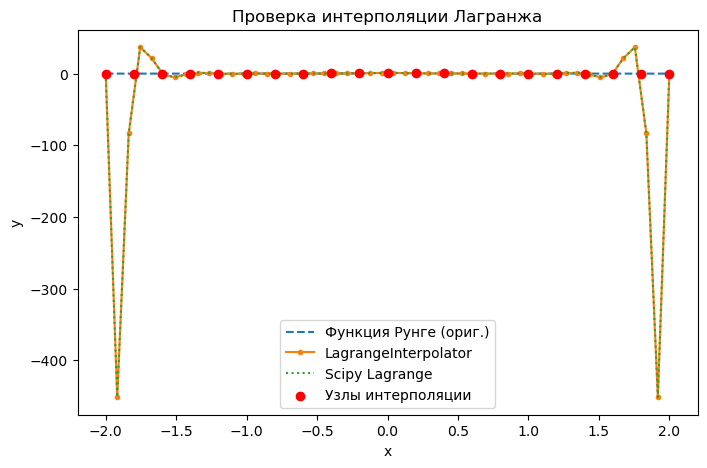

Тесты пройдены!


In [5]:
#test
test_x = np.linspace(-2, 2, 50)
test_y = runge_func(test_x)
interp_y = np.array([lagr(x) for x in test_x])

# Сравнение с библиотечной интерполяцией
sci_lagr = lagrange(xx, yy)
sci_interp_y = sci_lagr(test_x)

# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(test_x, test_y, label="Функция Рунге (ориг.)", linestyle="dashed")
plt.plot(test_x, interp_y, label="LagrangeInterpolator", marker="o", markersize=3)
plt.plot(test_x, sci_interp_y, label="Scipy Lagrange", linestyle="dotted")
plt.scatter(xx, yy, color='red', label="Узлы интерполяции", zorder=3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Проверка интерполяции Лагранжа")
plt.show()

print("Тесты пройдены!")

## Задача 3

### Uniform distribution

In [6]:
def runge_func(x):
    return 1 / (1 + 25 * x**2)

ms = [3, 5, 7, 11]

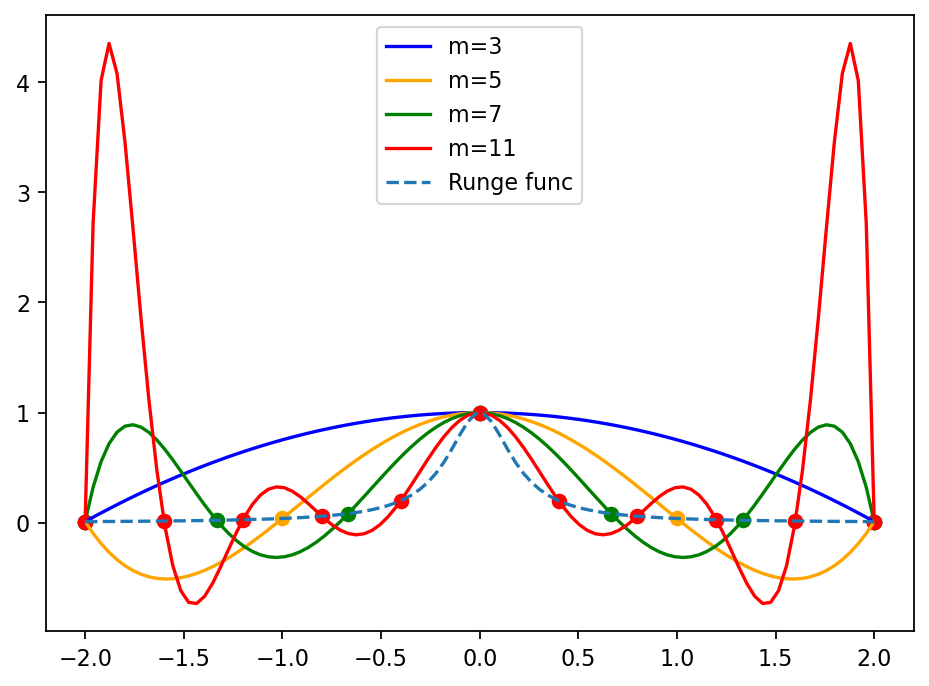

In [7]:
from sympy.polys.polyfuncs import interpolate

colors = ['blue', 'orange', 'green', 'red']

t = smp.Symbol('t')
plt.figure(figsize=(7, 5), dpi=160)
for i, m in enumerate(ms):
    x = np.linspace(-2, 2, m)
    points = [(x[i], runge_func(x[i])) for i in range(m)]
    f = smp.lambdify(t, interpolate(points, t), 'numpy')
    x_continious = np.linspace(-2, 2, 100)
    plt.scatter(x, runge_func(x), color=colors[i])
    plt.plot(x_continious, f(x_continious), label=f'm={m}', color=colors[i])
plt.plot(x_continious, runge_func(x_continious), linestyle='--', label='Runge func')
plt.legend()
plt.show()

### Chebyshev distribution

In [8]:
def cheb_nodes(n, a=-1, b=1):
    r"""Chebyshev nodes of degree $n$ on $[a, b]$
    """
    return [((a + b) / 2 + (b - a) / 2 * np.cos((2 * (k) + 1) / 2 / (n) * np.pi)) for k in range(n)][::-1]

In [9]:
cheb_nodes(5, -1, 3)

[-0.9021130325903071,
 -0.17557050458494605,
 1.0000000000000002,
 2.1755705045849463,
 2.9021130325903073]

In [10]:
from scipy.special import roots_chebyt
roots_chebyt(5)

(array([-0.95105652, -0.58778525,  0.        ,  0.58778525,  0.95105652]),
 array([0.62831853, 0.62831853, 0.62831853, 0.62831853, 0.62831853]))

In [11]:
from numpy.testing import assert_allclose

nodes_11 = cheb_nodes(11)
nodes_11 = np.asarray(nodes_11)
assert (nodes_11[1:] > nodes_11[:-1]).all()

from scipy.special import roots_chebyt
nodes, weights = roots_chebyt(5)

assert_allclose(cheb_nodes(5),
                nodes, atol=1e-14)

assert_allclose(cheb_nodes(5, a=-1, b=3),
                nodes*2 + 1, atol=1e-14)

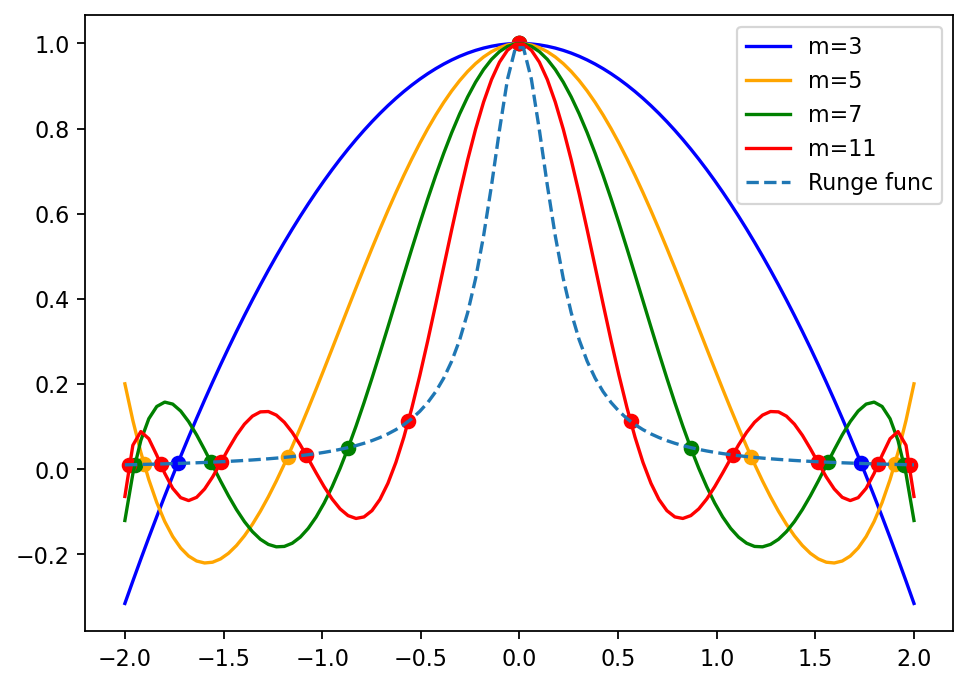

In [12]:
from sympy.polys.polyfuncs import interpolate

colors = ['blue', 'orange', 'green', 'red']

t = smp.Symbol('t')
plt.figure(figsize=(7, 5), dpi=160)
for i, m in enumerate(ms):
    x = cheb_nodes(m, -2, 2)
    points = [(x[i], runge_func(x[i])) for i in range(m)]
    f = smp.lambdify(t, interpolate(points, t), 'numpy')
    x_continious = np.linspace(-2, 2, 100)
    plt.scatter(x, runge_func(np.array(x)), color=colors[i])
    plt.plot(x_continious, f(x_continious), label=f'm={m}', color=colors[i])
plt.plot(x_continious, runge_func(x_continious), linestyle='--', label='Runge func')
plt.legend()
plt.show()

### Cubic spline 

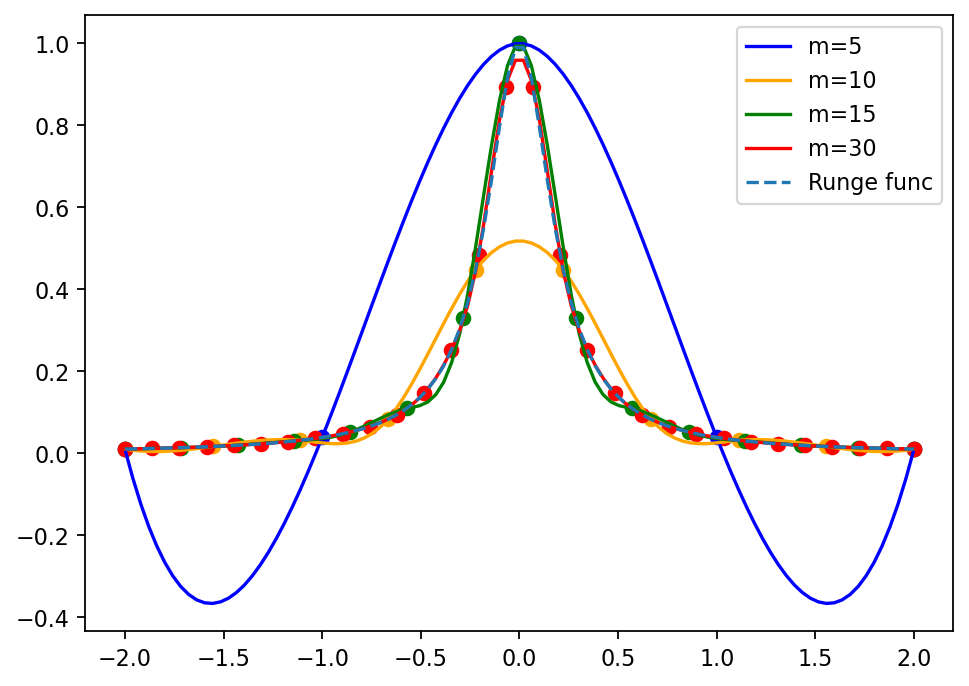

In [13]:
from scipy import interpolate

colors = ['blue', 'orange', 'green', 'red']
ms = [5, 10, 15, 30]

t = smp.Symbol('t')
plt.figure(figsize=(7, 5), dpi=160)
for i, m in enumerate(ms):
    x = np.linspace(-2, 2, m)
    f = interpolate.interp1d(x, runge_func(x), kind = 'cubic')
    x_continious = np.linspace(-2, 2, 100)
    plt.scatter(x, runge_func(x), color=colors[i])
    plt.plot(x_continious, f(x_continious), label=f'm={m}', color=colors[i])
plt.plot(x_continious, runge_func(x_continious), linestyle='--', label='Runge func')
plt.legend()
plt.show()

## Задача 4

Если ошибки измерений нормальные с дисперсией $\sigma^2 = 0.25$, то разумным выбором s является s ≈ n * 0.25, где n — число точек, согласно документации.

In [14]:
def func(x):
    return 5 * np.sin(2 * x)

In [15]:
n = 30
x = np.linspace(-np.pi, np.pi, n)
y = func(x) + 0.5 * np.random.randn(n)

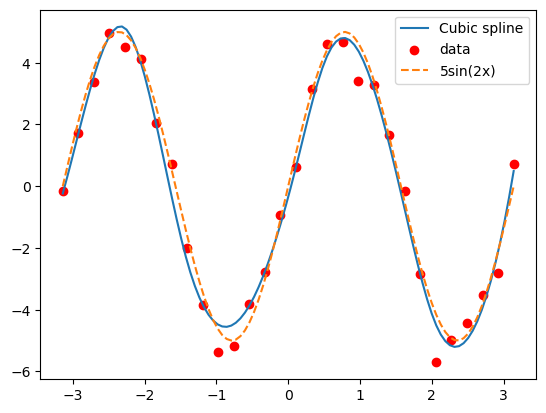

In [16]:
from scipy.interpolate import UnivariateSpline

s = n * 0.25
spline = UnivariateSpline(x, y, s=s)
x_continious = np.linspace(-np.pi, np.pi, 100)

plt.plot(x_continious, spline(x_continious), label='Cubic spline')
plt.scatter(x, y, color='red', label='data')
plt.plot(x_continious, func(x_continious), linestyle='--', label='5sin(2x)')
plt.legend()
plt.show()

## Задача 5

-4.0*sin(0.04*t)/(t/200 + 1) - (0.5*cos(0.04*t) + 0.5)/(t/200 + 1)**2


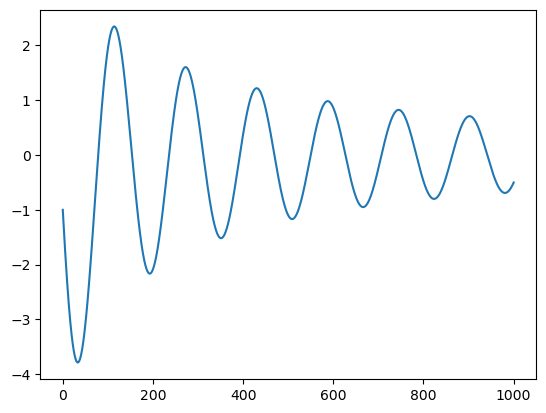

In [17]:
#Точное решение

t = smp.symbols('t')
u_corr = 200 / (1 + t/200) * (0.5 + 0.5 * smp.cos(0.04 * t))

du_corr = smp.diff(u_corr, t)

print(du_corr)
du_corr = smp.lambdify(t, du_corr, 'numpy')
x_continious = np.linspace(0, 1000, 10000)

plt.plot(x_continious, du_corr(x_continious))

In [18]:
n = 1000
t = np.linspace(0, 1000, n)
u = 200 / (1 + t/200) * (0.5 + 0.5 * np.cos(0.04 * t)) + 0.5 * np.random.randn(len(t))

In [19]:
dt = 1000 / n
#Конечные разности
du_1 = [(u[i+1] - u[i]) / dt for i in range(n-1)]

Оптимальный шаг вычисляется по формуле $h^* = 2 \sqrt{\frac{\Delta f}{M}}$. $\Delta f = 0.5$, а максимум второй производной оценим $M=0.15$, тогда оптимальный шаг $h^* \approx 4$.

In [20]:
#Конечные разности  с оптимальным шагом
du_2 = [(u[i+4] - u[i]) / 4 for i in range(n-4)]

In [21]:
#Сплайн
s = n * 0.25
dspline = UnivariateSpline(t, u, s=s).derivative()
du_3 = dspline(x_continious)

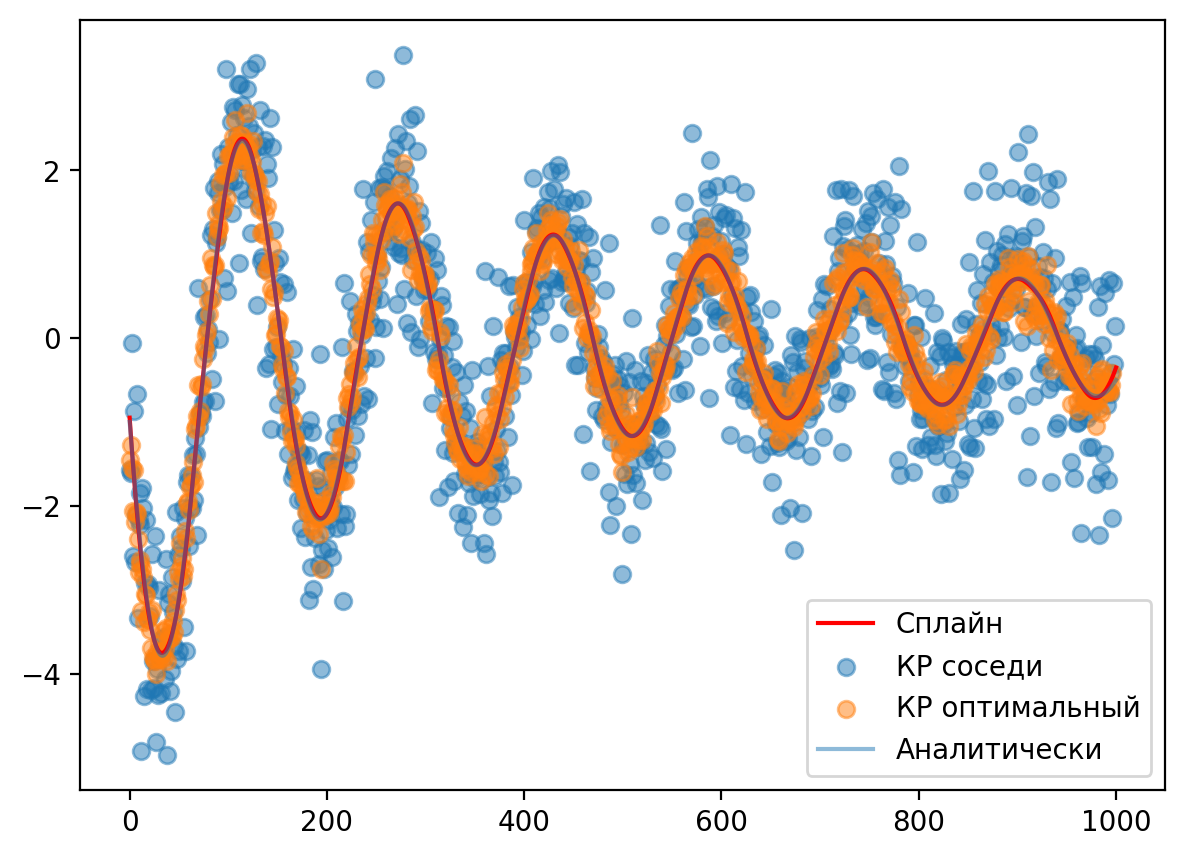

In [22]:
plt.figure(figsize=(7, 5), dpi=200)
plt.plot(x_continious, du_3, color='red', label='Сплайн')
plt.scatter(t[:-1], du_1, label='КР соседи', alpha=0.5)
plt.scatter(t[:-4], du_2, label='КР оптимальный', alpha=0.5)
plt.plot(x_continious, du_corr(x_continious), label='Аналитически', alpha=0.5)
plt.legend()
plt.show()


In [23]:
from sklearn.metrics import mean_squared_error as mse

print("MSE КР соседние:", mse(du_corr(t)[:-1], du_1))
print("MSE КР оптимальный шаг:", mse(du_corr(t)[:-4], du_2))
print("MSE сплайн:", mse(du_corr(t), dspline(t)))

MSE КР соседние: 0.5160064361641553
MSE КР оптимальный шаг: 0.04044609254192383
MSE сплайн: 0.00043109680358355295


Вывод: поиск производной путем дифференцирования сплайн дал наилучший результат, с точностью $1e-4$ совпадающий с аналитическим решением. Решение полученное через конечные разности с оптимальным шагом получилось на порядок лучше, чем на соседних точках.